# Relative EKF Exploration — Day 02 Flapper Data

**3 drones:** Drone 0 (static ground beacon), Drone 1 & 2 (flying Flappers)

**Data:** `synced_all.csv` — 50 Hz, time-aligned onboard sensors + OptiTrack mocap ground truth  
**EKF:** 3-state relative position estimator: $[\psi_{12}, x_{12}, y_{12}]$ (relative yaw + body-frame position)  
**Measurement:** UWB inter-drone range only

This notebook lets you interactively explore the data, run the EKF with different tuning, and compare against mocap ground truth.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

In [6]:
df = pd.read_csv("../relative_data/day_02/synced_all_500hz.csv")
print(f"Shape: {df.shape}")
print(f"Time range: {df['time'].iloc[0]:.1f} – {df['time'].iloc[-1]:.1f} s  ({len(df)} rows @ ~50 Hz)")
print(f"\nColumns ({len(df.columns)}):")
for c in df.columns:
    print(f"  {c}")
df.head(3)

Shape: (29953, 106)
Time range: 13.7 – 73.6 s  (29953 rows @ ~50 Hz)

Columns (106):
  time
  d0_distance1
  d0_distance2
  d0_inD12
  d0_inD21
  d0_height0
  d0_height1
  d0_height2
  d0_yawR1
  d0_yawR2
  d0_vx1
  d0_vx2
  d0_vy1
  d0_vy2
  d0_vz1
  d0_vz2
  d0_kalman_stateZ
  d0_kalman_statePX
  d0_kalman_statePY
  d0_kalman_statePZ
  d0_rateYaw
  d1_distance0
  d1_distance2
  d1_inD02
  d1_inD20
  d1_height0
  d1_height1
  d1_height2
  d1_yawR0
  d1_yawR2
  d1_vx0
  d1_vx2
  d1_vy0
  d1_vy2
  d1_vz0
  d1_vz2
  d1_kalman_stateZ
  d1_kalman_statePX
  d1_kalman_statePY
  d1_kalman_statePZ
  d1_rateYaw
  d2_distance0
  d2_distance1
  d2_inD01
  d2_inD10
  d2_height0
  d2_height1
  d2_height2
  d2_yawR0
  d2_yawR1
  d2_vx0
  d2_vx1
  d2_vy0
  d2_vy1
  d2_vz0
  d2_vz1
  d2_kalman_stateZ
  d2_kalman_statePX
  d2_kalman_statePY
  d2_kalman_statePZ
  d2_rateYaw
  mc0_cf_x
  mc0_cf_y
  mc0_cf_z
  mc0_roll
  mc0_pitch
  mc0_yaw
  mc0_vx_body
  mc0_vy_body
  mc0_vz_body
  mc0_yawrate
  mc1_cf_

,time,d0_distance1,d0_distance2,d0_inD12,d0_inD21,d0_height0,d0_height1,d0_height2,d0_yawR1,d0_yawR2,...,mc_dist_02,mc_rel_02_x,mc_rel_02_y,mc_rel_02_z,mc_rel_02_yaw,mc_dist_12,mc_rel_12_x,mc_rel_12_y,mc_rel_12_z,mc_rel_12_yaw
0,13.720668,1042.616987,1177.0,2458.0,2456.0,0.0,0.020019,0.019993,0.033585,0.036988,...,1.387519,0.195245,-1.373713,0.000452,-0.001487,2.662532,-0.621285,-2.589028,-0.003904,-0.298538
1,13.722668,978.000000,1177.0,2458.0,2456.0,0.0,0.020019,0.019993,0.150753,0.036988,...,1.387507,0.195059,-1.373728,0.000455,-0.001636,2.662533,-0.621263,-2.589034,-0.003909,-0.298540
2,13.724668,978.313954,1177.0,2458.0,2456.0,0.0,0.020019,0.019993,0.150947,0.036988,...,1.387509,0.195251,-1.373703,0.000448,-0.001580,2.662547,-0.621461,-2.589001,-0.003939,-0.298708


## Column naming convention

| Pattern | Meaning | Units |
|---------|---------|-------|
| `d{i}_distance{j}` | UWB range from drone i to j | **mm** (÷1000 for m) |
| `d{i}_yawR{j}` | Communicated yaw rate from j, logged by i | **deg/s** |
| `d{i}_vx{j}`, `vy{j}`, `vz{j}` | Communicated body-frame velocity of j | m/s |
| `d{i}_height{j}` | Communicated height of j | m |
| `d{i}_kalman_stateZ` | Drone i's own height estimate | m |
| `d{i}_kalman_statePX/PY/PZ` | Drone i's own body-frame velocity | m/s |
| `d{i}_rateYaw` | Drone i's own gyro yaw rate | **millirad/s** (÷1000 for rad/s) |
| `mc{i}_cf_x/y/z` | Mocap position in CF frame | m |
| `mc{i}_yaw` | Mocap heading | rad |
| `mc{i}_vx_body`, `vy_body` | Mocap-derived body-frame velocity | m/s |
| `mc{i}_yawrate` | Mocap-derived yaw rate | rad/s |
| `mc_dist_{ij}` | Mocap Euclidean distance i↔j | m |
| `mc_rel_{ij}_x/y/z` | Body-frame relative position of j from i's frame | m |
| `mc_rel_{ij}_yaw` | Relative heading j − i | rad |

**Frame convention:** `cf_x = optitrack_z`, `cf_y = optitrack_x`, `cf_z = optitrack_y`  
**Drone 0** is static on the ground — all its velocities, yaw rate, and height are zero.

dt: mean=0.0020s, std=0.0000s, min=0.0020s, max=0.0020s


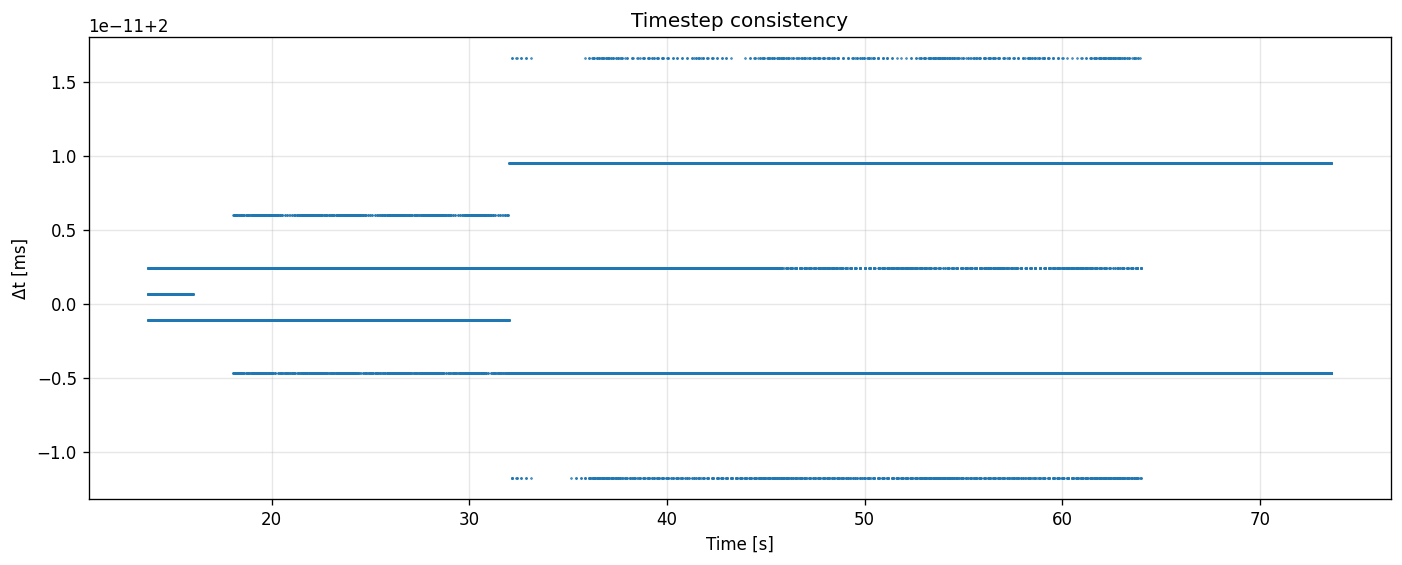

In [7]:
# Check time alignment — should be ~0.02s (50 Hz) between rows
dt = np.diff(df['time'].values)
print(f"dt: mean={dt.mean():.4f}s, std={dt.std():.4f}s, min={dt.min():.4f}s, max={dt.max():.4f}s")

fig, ax = plt.subplots()
ax.plot(df['time'].values[1:], dt * 1000, '.', ms=1)
ax.set_xlabel("Time [s]"); ax.set_ylabel("Δt [ms]")
ax.set_title("Timestep consistency"); ax.grid(True, alpha=0.3)
plt.show()

In [8]:
# Summary statistics for key columns
key_cols = [
    'mc0_cf_x', 'mc0_cf_y', 'mc0_cf_z',
    'mc1_cf_x', 'mc1_cf_y', 'mc1_cf_z', 'mc1_yaw',
    'mc2_cf_x', 'mc2_cf_y', 'mc2_cf_z', 'mc2_yaw',
    'd1_kalman_statePX', 'd1_kalman_statePY', 'd1_rateYaw',
    'd2_kalman_statePX', 'd2_kalman_statePY', 'd2_rateYaw',
    'd0_distance1', 'd0_distance2', 'd1_distance2',
    'mc_dist_01', 'mc_dist_02', 'mc_dist_12',
]
df[key_cols].describe().round(3)

,mc0_cf_x,mc0_cf_y,mc0_cf_z,mc1_cf_x,mc1_cf_y,mc1_cf_z,mc1_yaw,mc2_cf_x,mc2_cf_y,mc2_cf_z,...,d1_rateYaw,d2_kalman_statePX,d2_kalman_statePY,d2_rateYaw,d0_distance1,d0_distance2,d1_distance2,mc_dist_01,mc_dist_02,mc_dist_12
count,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000,...,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000,29953.000
mean,-0.008,-0.007,0.123,-0.159,-0.491,1.042,-0.564,0.338,-0.960,1.016,...,427.252,0.292,0.000,74.144,1790.745,2102.766,2688.774,2.016,2.301,2.804
std,0.000,0.000,0.000,1.698,0.744,0.288,1.700,1.546,1.246,0.311,...,3331.007,0.187,0.071,3955.389,738.003,768.931,1087.230,0.745,0.757,1.033
min,-0.009,-0.007,0.122,-3.487,-1.755,0.127,-3.139,-1.488,-3.255,0.121,...,-13648.296,-0.236,-0.263,-15457.811,423.531,744.000,806.000,0.732,1.010,1.089
25%,-0.008,-0.007,0.123,-1.445,-1.121,0.901,-1.715,-0.898,-1.906,0.885,...,-1751.761,0.234,-0.039,-2448.368,1208.000,1528.000,2052.000,1.442,1.759,2.142
50%,-0.008,-0.007,0.123,0.310,-0.510,1.087,-0.943,-0.036,-0.957,1.072,...,183.628,0.319,0.000,1.783,1614.386,2000.000,2460.000,1.791,2.123,2.607
75%,-0.008,-0.007,0.123,1.262,-0.026,1.252,0.624,1.164,0.205,1.248,...,2575.646,0.406,0.038,2607.277,2293.000,2564.933,3219.000,2.552,2.745,3.191
max,-0.007,-0.006,0.123,2.205,1.485,1.408,3.139,3.964,1.033,1.402,...,14249.361,0.844,0.392,17385.028,3734.000,3919.000,5738.000,3.803,4.076,5.725


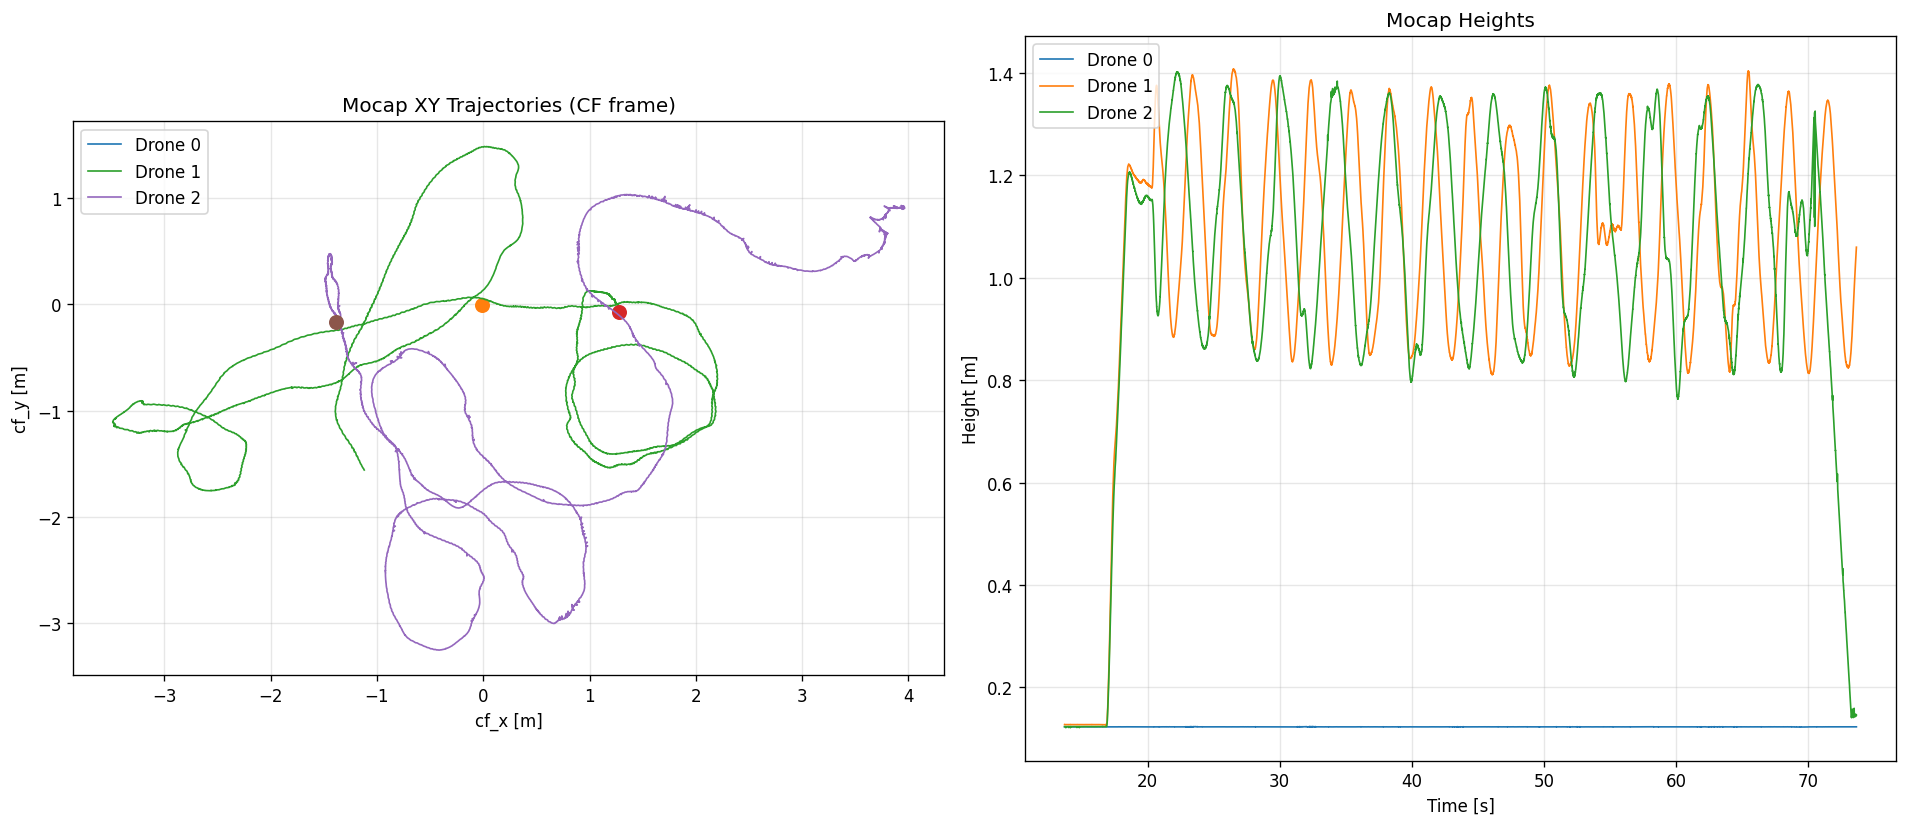

In [9]:
# Mocap trajectories — XY plane (CF frame)
t = df['time'].values
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.set_title("Mocap XY Trajectories (CF frame)")
for d in [0, 1, 2]:
    ax.plot(df[f'mc{d}_cf_x'], df[f'mc{d}_cf_y'], label=f'Drone {d}', lw=1)
    ax.plot(df[f'mc{d}_cf_x'].iloc[0], df[f'mc{d}_cf_y'].iloc[0], 'o', ms=8)
ax.set_xlabel("cf_x [m]"); ax.set_ylabel("cf_y [m]")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

ax = axes[1]
ax.set_title("Mocap Heights")
for d in [0, 1, 2]:
    ax.plot(t, df[f'mc{d}_cf_z'], label=f'Drone {d}', lw=1)
ax.set_xlabel("Time [s]"); ax.set_ylabel("Height [m]")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

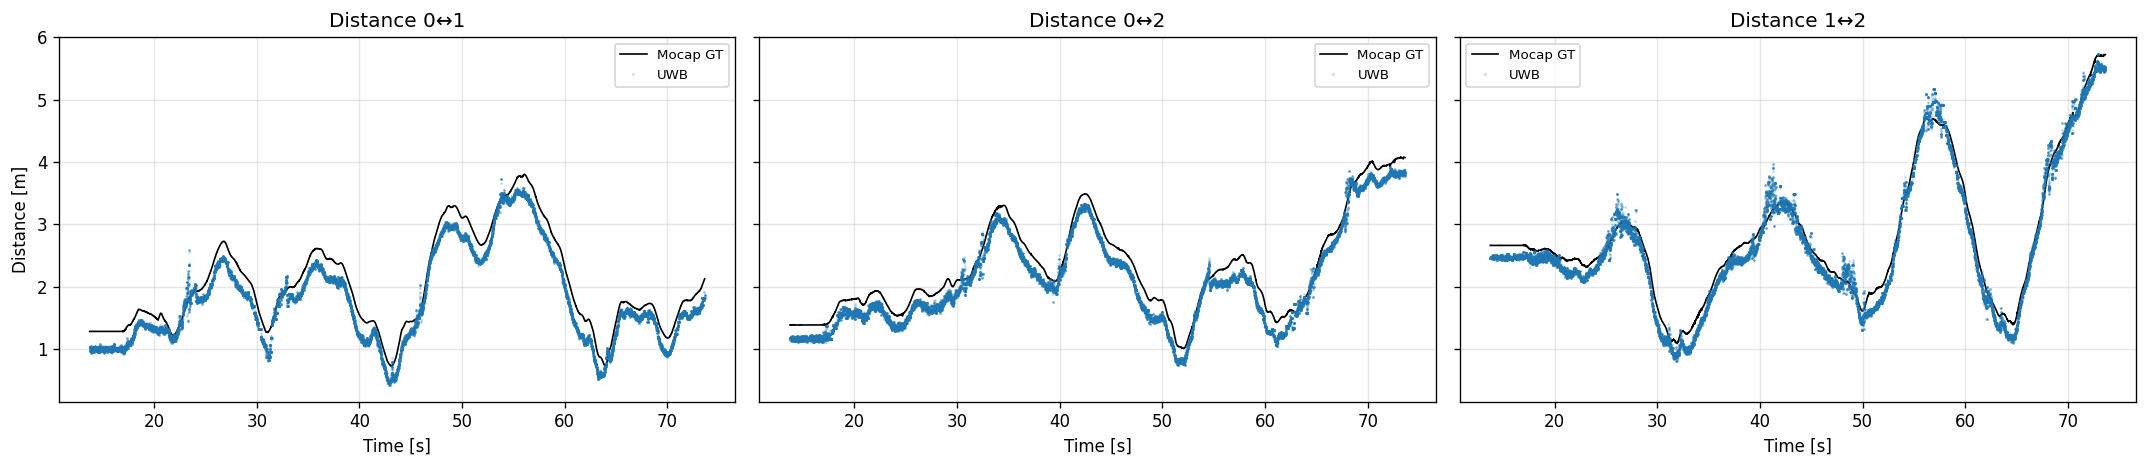

In [10]:
# UWB distance vs mocap distance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
pairs = [('0', '1'), ('0', '2'), ('1', '2')]
for ax, (i, j) in zip(axes, pairs):
    d_uwb = df[f'd{i}_distance{j}'] / 1000.0  # mm → m
    d_mc = df[f'mc_dist_{i}{j}']
    ax.plot(t, d_mc, 'k-', lw=1, label='Mocap GT')
    ax.plot(t, d_uwb, '.', ms=1, alpha=0.3, label='UWB')
    ax.set_title(f'Distance {i}↔{j}'); ax.set_xlabel('Time [s]')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Distance [m]')
plt.tight_layout(); plt.show()

## Filtering helper — subsetting data

Use these to zoom in on specific time ranges or extract per-drone columns.

In [11]:
# Filter by time range
def time_slice(df, t_start, t_end):
    """Return rows where t_start <= time <= t_end."""
    return df[(df['time'] >= t_start) & (df['time'] <= t_end)].copy()

# Get columns for a specific drone
def drone_cols(df, drone_id):
    """Return columns related to a specific drone."""
    return [c for c in df.columns if f'd{drone_id}_' in c or f'mc{drone_id}_' in c]

# Example: first 10 seconds of flight
df_early = time_slice(df, df['time'].iloc[0], df['time'].iloc[0] + 10)
print(f"Early slice: {len(df_early)} rows, {df_early['time'].iloc[0]:.1f}–{df_early['time'].iloc[-1]:.1f} s")

Early slice: 5000 rows, 13.7–23.7 s


---

## EKF Setup

The 3-state relative EKF estimates drone j's position relative to drone i, expressed in drone i's body frame:

$$\mathbf{x} = [\psi_{12},\; x_{12},\; y_{12}]$$

**Dynamics** use body-frame velocities and yaw rates from both drones.  
**Measurement** is scalar UWB range: $d = \sqrt{x_{12}^2 + y_{12}^2 + z_{12}^2}$

In [12]:
# ── EKF utilities (from ekf_utils.py) ──────────────────────────────

def wrapToPi(rad):
    """Wrap angle(s) to [-π, π)."""
    rad = np.asarray(rad, dtype=float)
    return (rad + np.pi) % (2 * np.pi) - np.pi

def jacobian_numerical(f, x, u, epsilon=1e-6):
    """Central-difference numerical Jacobian ∂f/∂x."""
    x = np.asarray(x, dtype=np.float64)
    u = np.asarray(u, dtype=np.float64)
    n = len(x)
    f0 = np.atleast_1d(f(x, u))
    m = len(f0)
    J = np.zeros((m, n))
    for i in range(n):
        x_plus = x.copy();  x_plus[i] += epsilon
        x_minus = x.copy(); x_minus[i] -= epsilon
        J[:, i] = (np.atleast_1d(f(x_plus, u)) - np.atleast_1d(f(x_minus, u))) / (2.0 * epsilon)
    return J

def rk4_discretize(f, x, u, dt):
    """RK4 integration."""
    k1 = f(x, u)
    k2 = f(x + 0.5 * dt * k1, u)
    k3 = f(x + 0.5 * dt * k2, u)
    k4 = f(x + dt * k3, u)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

class EKF:
    """Extended Kalman Filter with numerical Jacobians and Joseph-form update."""

    def __init__(self, f, h, x0, u0, P0, Q, R,
                 circular_measurements=None,
                 dynamics_type='discrete',
                 discretization_timestep=None):
        self.f = f
        self.h = h
        self.dynamics_type = dynamics_type
        self.discretization_timestep = discretization_timestep

        self.x = np.atleast_1d(np.array(x0, dtype=float))
        self.u = np.atleast_1d(np.array(u0, dtype=float))
        # Don't propagate x0 — just store it as the initial state.
        # forward_update will propagate on each subsequent step.
        self.z0 = np.atleast_1d(self.h(self.x, self.u))

        self.n = self.x.shape[0]
        self.p = self.z0.shape[0]
        self.circular_measurements = tuple(
            circular_measurements if circular_measurements else np.zeros(self.p, dtype=bool))

        self.P = np.array(P0, dtype=float)
        self.Q = np.array(Q, dtype=float)
        self.R = np.array(R, dtype=float)

        self.history = {
            'X': [self.x.copy()], 'P_diags': [np.diag(self.P)],
        }

    def f_discrete(self, x, u):
        if self.dynamics_type == 'continuous':
            return rk4_discretize(self.f, x, u, self.discretization_timestep)
        return np.atleast_1d(self.f(x, u))

    def forward_update(self, z, u, discretization_timestep=None):
        """Combined predict + update."""
        if discretization_timestep is not None and self.dynamics_type == 'continuous':
            self.discretization_timestep = discretization_timestep
        self.u = np.atleast_1d(np.array(u, dtype=float))

        # Predict
        self.x = self.f_discrete(self.x, self.u)
        F = jacobian_numerical(self.f_discrete, self.x, self.u)
        self.P = F @ self.P @ F.T + self.Q

        # Update
        z = np.atleast_1d(np.array(z, dtype=float))
        z_pred = np.atleast_1d(self.h(self.x, self.u))
        y = np.array([wrapToPi(z[j] - z_pred[j]) if self.circular_measurements[j]
                       else z[j] - z_pred[j] for j in range(self.p)])
        H = jacobian_numerical(self.h, self.x, self.u)
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y

        # Joseph form covariance update
        I = np.eye(self.n)
        ImKH = I - K @ H
        self.P = ImKH @ self.P @ ImKH.T + K @ self.R @ K.T

        self.history['X'].append(self.x.copy())
        self.history['P_diags'].append(np.diag(self.P))

print("EKF class loaded ✓")

EKF class loaded ✓


In [13]:
# ── 3-state dynamics & measurement models ─────────────────────────

def f_3state(x, u):
    """Continuous dynamics: state = [psi12, x12, y12]
    u = [omega_i, vxi, vyi, vzi, omega_j, vxj, vyj, vzj, z12]
    """
    psi12, x12, y12 = x
    psi_dot_i, vxi, vyi, _vzi, psi_dot_j, vxj, vyj, _vzj, _z12 = u[:9]
    c, s = np.cos(psi12), np.sin(psi12)
    return np.array([
        psi_dot_j - psi_dot_i,
        (c * vxj - s * vyj) - vxi + psi_dot_i * y12,
        (s * vxj + c * vyj) - vyi - psi_dot_i * x12,
    ])

def h_3state(x, u):
    """Measurement: range = sqrt(x12² + y12² + z12²)"""
    _, x12, y12 = x
    z12 = u[8]
    d = np.sqrt(x12**2 + y12**2 + z12**2)
    return np.array([max(d, 1e-8)])

STATIC_DRONE = 0

In [14]:

# ── Extract pair data from CSV ─────────────────────────────────────

def extract_pair_data(df, i, j):
    """Extract EKF inputs for pair i→j from synced CSV (onboard sensors).
    
    Drone 0 (beacon): zeroed velocity, yaw rate, height.
    Unit conversions:
      - d{i}_rateYaw: millirad/s → rad/s (÷1000)
      - d{i}_yawR{j}: deg/s → rad/s
      - d{i}_distance{j}: mm → m (÷1000)
    """
    N = len(df)

    # Observer (drone i)
    if i == STATIC_DRONE:
        omega_i = np.zeros(N)
        vxi, vyi, vzi = np.zeros(N), np.zeros(N), np.zeros(N)
        h_i = np.zeros(N)
    else:
        omega_i = df[f'd{i}_rateYaw'].values / 1000.0
        vxi = df[f'd{i}_kalman_statePX'].values
        vyi = df[f'd{i}_kalman_statePY'].values
        vzi = df[f'd{i}_kalman_statePZ'].values
        h_i = df[f'd{i}_kalman_stateZ'].values

    # Target (drone j) — communicated to i via UWB
    if j == STATIC_DRONE:
        omega_j = np.zeros(N)
        vxj, vyj, vzj = np.zeros(N), np.zeros(N), np.zeros(N)
        h_j = np.zeros(N)
    else:
        omega_j = np.deg2rad(df[f'd{i}_yawR{j}'].values)
        vxj = df[f'd{i}_vx{j}'].values
        vyj = df[f'd{i}_vy{j}'].values
        vzj = df[f'd{i}_vz{j}'].values
        h_j = df[f'd{i}_height{j}'].values

    d_meas = df[f'd{i}_distance{j}'].values / 1000.0
    z12 = h_j - h_i

    return {
        'omega_i': omega_i, 'vxi': vxi, 'vyi': vyi, 'vzi': vzi,
        'omega_j': omega_j, 'vxj': vxj, 'vyj': vyj, 'vzj': vzj,
        'd_meas': d_meas, 'z12': z12,
    }


def extract_pair_data_mocap(df, i, j):
    """Extract EKF inputs for pair i→j from mocap ground truth.
    
    Uses mc{k}_vx_body, mc{k}_vy_body, mc{k}_yawrate, mc{k}_cf_z
    and mocap-derived 3D distance.
    """
    N = len(df)

    # Observer (drone i)
    if i == STATIC_DRONE:
        omega_i = np.zeros(N)
        vxi, vyi, vzi = np.zeros(N), np.zeros(N), np.zeros(N)
        h_i = np.zeros(N)
    else:
        omega_i = np.deg2rad(df[f'mc{i}_yawrate'].values)  # CSV is deg/s → rad/s
        vxi = df[f'mc{i}_vx_body'].values
        vyi = df[f'mc{i}_vy_body'].values
        vzi = df[f'mc{i}_vz_body'].values
        h_i = df[f'mc{i}_cf_z'].values

    # Target (drone j)
    if j == STATIC_DRONE:
        omega_j = np.zeros(N)
        vxj, vyj, vzj = np.zeros(N), np.zeros(N), np.zeros(N)
        h_j = np.zeros(N)
    else:
        omega_j = np.deg2rad(df[f'mc{j}_yawrate'].values)  # CSV is deg/s → rad/s
        vxj = df[f'mc{j}_vx_body'].values
        vyj = df[f'mc{j}_vy_body'].values
        vzj = df[f'mc{j}_vz_body'].values
        h_j = df[f'mc{j}_cf_z'].values

    # Mocap-derived distance (3D)
    xi, yi, zi = df[f'mc{i}_cf_x'].values, df[f'mc{i}_cf_y'].values, df[f'mc{i}_cf_z'].values
    xj, yj, zj = df[f'mc{j}_cf_x'].values, df[f'mc{j}_cf_y'].values, df[f'mc{j}_cf_z'].values
    d_meas = np.sqrt((xj - xi)**2 + (yj - yi)**2 + (zj - zi)**2)

    z12 = h_j - h_i

    return {
        'omega_i': omega_i, 'vxi': vxi, 'vyi': vyi, 'vzi': vzi,
        'omega_j': omega_j, 'vxj': vxj, 'vyj': vyj, 'vzj': vzj,
        'd_meas': d_meas, 'z12': z12,
    }


def get_mocap_gt(df, i, j):
    """Get mocap ground truth for pair i→j.

    CSV has mc_rel_{ij} only for (01, 02, 12).
    For reverse pairs, recompute from mocap positions.
    """
    key = f'{min(i,j)}{max(i,j)}'
    if i < j and f'mc_rel_{key}_x' in df.columns:
        return {
            'x12': df[f'mc_rel_{key}_x'].values,
            'y12': df[f'mc_rel_{key}_y'].values,
            'psi12': np.unwrap(df[f'mc_rel_{key}_yaw'].values),
            'dist': df[f'mc_dist_{key}'].values,
        }
    # Compute from raw mocap for reverse pairs
    xi, yi, zi = df[f'mc{i}_cf_x'].values, df[f'mc{i}_cf_y'].values, df[f'mc{i}_cf_z'].values
    xj, yj, zj = df[f'mc{j}_cf_x'].values, df[f'mc{j}_cf_y'].values, df[f'mc{j}_cf_z'].values
    yaw_i = df[f'mc{i}_yaw'].values
    yaw_j = df[f'mc{j}_yaw'].values
    dx, dy, dz = xj - xi, yj - yi, zj - zi
    c, s = np.cos(yaw_i), np.sin(yaw_i)
    return {
        'x12':  c * dx + s * dy,
        'y12': -s * dx + c * dy,
        'psi12': np.unwrap(yaw_j) - np.unwrap(yaw_i),
        'dist': np.sqrt(dx**2 + dy**2 + dz**2),
    }


In [15]:

# ── EKF tuning and runner ──────────────────────────────────────────

# Process noise — how much we trust the dynamics model
# Larger Q → less trust in model → more responsive to measurements
Q = np.diag([1e-5,   # ψ₁₂ yaw (rad²)
             1e-5,   # x₁₂ (m²)
             1e-5])  # y₁₂ (m²)

# Measurement noise — UWB range accuracy
# Smaller R → more trust in range measurement
R = np.array([[1e-5**2]])  # 10 cm std dev

# Initial covariance
P0 = np.diag([1e-5**2,   # ψ₁₂ uncertainty
              1e-5**2,   # x₁₂ uncertainty
              1e-5**2])  # y₁₂ uncertainty


def run_ekf(time, data, Q_use=None, R_use=None):
    """Run 3-state EKF. Returns (X, P_diags) arrays."""
    if Q_use is None: Q_use = Q
    if R_use is None: R_use = R

    N = len(time)
    dt_arr = np.diff(time)
    dt_med = float(np.median(dt_arr))

    d = data
    # Initialize x,y by splitting first distance equally: d/√2 each
    # so that sqrt(x0² + y0²) = d0
    d0 = d['d_meas'][0]
    x0 = np.array([0.0, d0 / np.sqrt(2), d0 / np.sqrt(2)])
    u0 = np.array([d['omega_i'][0], d['vxi'][0], d['vyi'][0], d['vzi'][0],
                    d['omega_j'][0], d['vxj'][0], d['vyj'][0], d['vzj'][0], d['z12'][0]])

    ekf = EKF(f_3state, h_3state, x0, u0,
              P0.copy(), Q_use.copy(), R_use.copy(),
              dynamics_type='continuous', discretization_timestep=dt_med)

    for k in range(1, N):
        dt_k = dt_arr[k-1] if k-1 < len(dt_arr) else dt_med
        u_k = np.array([d['omega_i'][k], d['vxi'][k], d['vyi'][k], d['vzi'][k],
                         d['omega_j'][k], d['vxj'][k], d['vyj'][k], d['vzj'][k], d['z12'][k]])
        ekf.forward_update(np.array([d['d_meas'][k]]), u_k, discretization_timestep=dt_k)

    return np.array(ekf.history['X']), np.array(ekf.history['P_diags'])


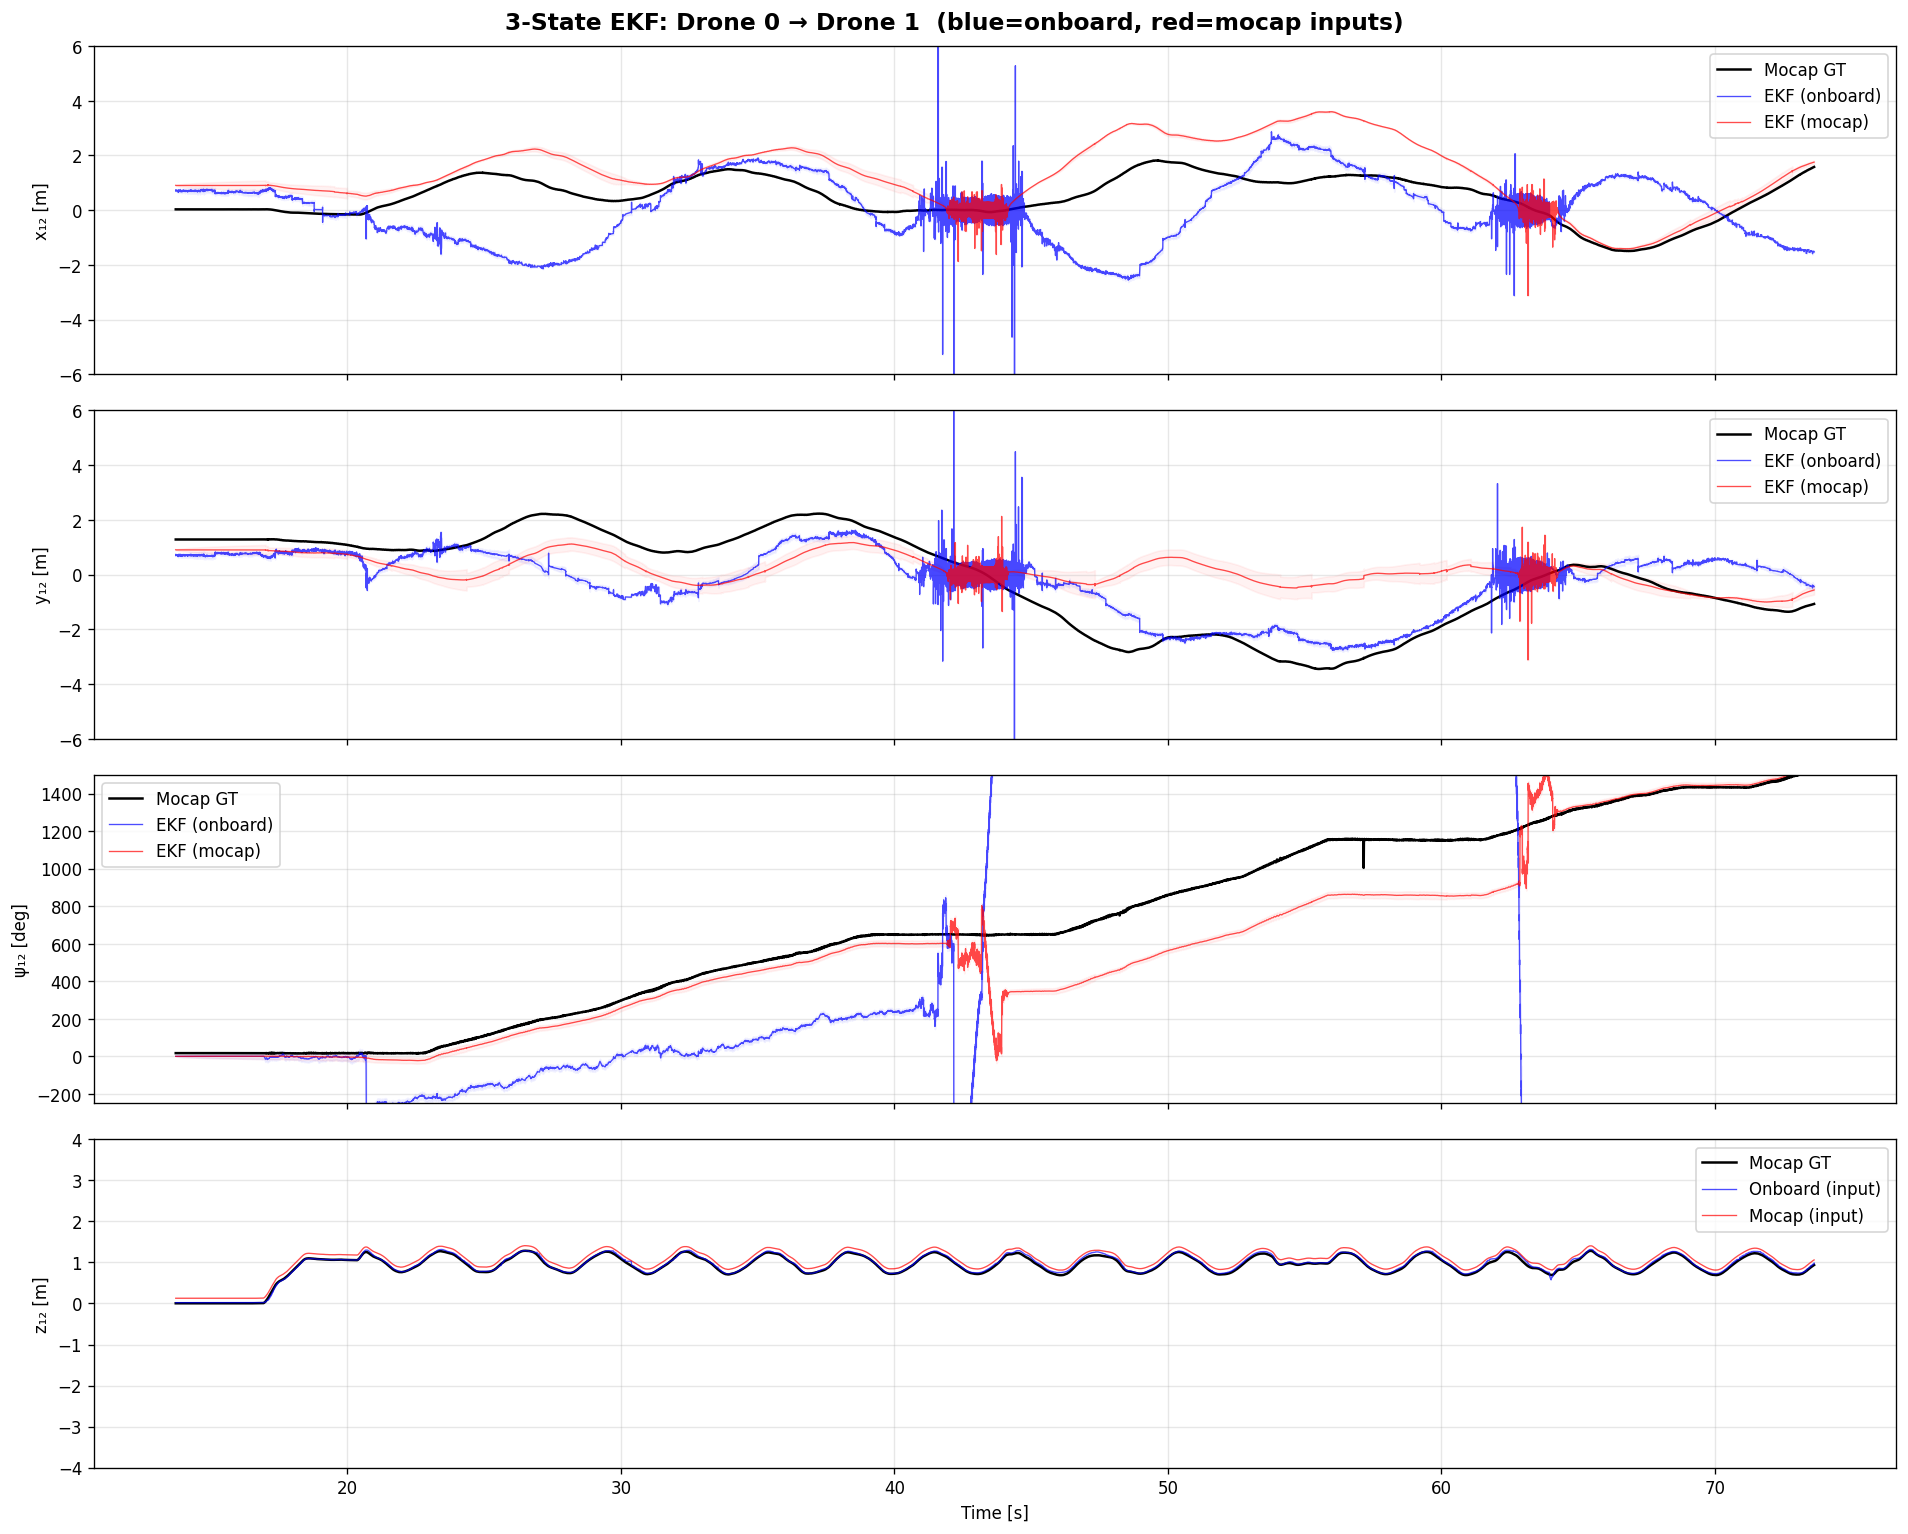

In [16]:

# ── Run EKF on pair: onboard vs mocap inputs ──────────────────────

i, j = 0, 1
time = df['time'].values

data_onboard = extract_pair_data(df, i, j)
data_mocap = extract_pair_data_mocap(df, i, j)
gt = get_mocap_gt(df, i, j)

X_ob, P_ob = run_ekf(time, data_onboard)
X_mc, P_mc = run_ekf(time, data_mocap)

# Mocap z12 ground truth
z12_mc = df[f'mc{j}_cf_z'].values - df[f'mc{i}_cf_z'].values

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)
fig.suptitle(f'3-State EKF: Drone {i} → Drone {j}  (blue=onboard, red=mocap inputs)', fontsize=14, fontweight='bold')

# x12
axes[0].plot(time, gt['x12'], 'k-', lw=1.5, label='Mocap GT')
axes[0].plot(time, X_ob[:, 1], 'b-', alpha=0.7, lw=0.8, label='EKF (onboard)')
axes[0].plot(time, X_mc[:, 1], 'r-', alpha=0.7, lw=0.8, label='EKF (mocap)')
axes[0].fill_between(time, X_ob[:, 1] - 2*np.sqrt(np.abs(P_ob[:, 1])),
                     X_ob[:, 1] + 2*np.sqrt(np.abs(P_ob[:, 1])), color='b', alpha=0.05)
axes[0].fill_between(time, X_mc[:, 1] - 2*np.sqrt(np.abs(P_mc[:, 1])),
                     X_mc[:, 1] + 2*np.sqrt(np.abs(P_mc[:, 1])), color='r', alpha=0.05)
axes[0].set_ylabel('x₁₂ [m]'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-6, 6)

# y12
axes[1].plot(time, gt['y12'], 'k-', lw=1.5, label='Mocap GT')
axes[1].plot(time, X_ob[:, 2], 'b-', alpha=0.7, lw=0.8, label='EKF (onboard)')
axes[1].plot(time, X_mc[:, 2], 'r-', alpha=0.7, lw=0.8, label='EKF (mocap)')
axes[1].fill_between(time, X_ob[:, 2] - 2*np.sqrt(np.abs(P_ob[:, 2])),
                     X_ob[:, 2] + 2*np.sqrt(np.abs(P_ob[:, 2])), color='b', alpha=0.05)
axes[1].fill_between(time, X_mc[:, 2] - 2*np.sqrt(np.abs(P_mc[:, 2])),
                     X_mc[:, 2] + 2*np.sqrt(np.abs(P_mc[:, 2])), color='r', alpha=0.05)
axes[1].set_ylabel('y₁₂ [m]'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-6, 6)

# psi12
axes[2].plot(time, np.rad2deg(gt['psi12']), 'k-', lw=1.5, label='Mocap GT')
axes[2].plot(time, np.rad2deg(X_ob[:, 0]), 'b-', alpha=0.7, lw=0.8, label='EKF (onboard)')
axes[2].plot(time, np.rad2deg(X_mc[:, 0]), 'r-', alpha=0.7, lw=0.8, label='EKF (mocap)')
s = np.rad2deg(1.0)
axes[2].fill_between(time, np.rad2deg(X_ob[:, 0]) - 2*s*np.sqrt(np.abs(P_ob[:, 0])),
                     np.rad2deg(X_ob[:, 0]) + 2*s*np.sqrt(np.abs(P_ob[:, 0])), color='b', alpha=0.05)
axes[2].fill_between(time, np.rad2deg(X_mc[:, 0]) - 2*s*np.sqrt(np.abs(P_mc[:, 0])),
                     np.rad2deg(X_mc[:, 0]) + 2*s*np.sqrt(np.abs(P_mc[:, 0])), color='r', alpha=0.05)
axes[2].set_ylabel('ψ₁₂ [deg]')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-250, 1500)

# z12 — measured input (not estimated)
axes[3].plot(time, z12_mc, 'k-', lw=1.5, label='Mocap GT')
axes[3].plot(time, data_onboard['z12'], 'b-', alpha=0.7, lw=0.8, label='Onboard (input)')
axes[3].plot(time, data_mocap['z12'], 'r-', alpha=0.7, lw=0.8, label='Mocap (input)')
axes[3].set_ylabel('z₁₂ [m]'); axes[3].set_xlabel('Time [s]')
axes[3].legend(); axes[3].grid(True, alpha=0.3)
axes[3].set_ylim(-4, 4)

plt.tight_layout(); plt.show()


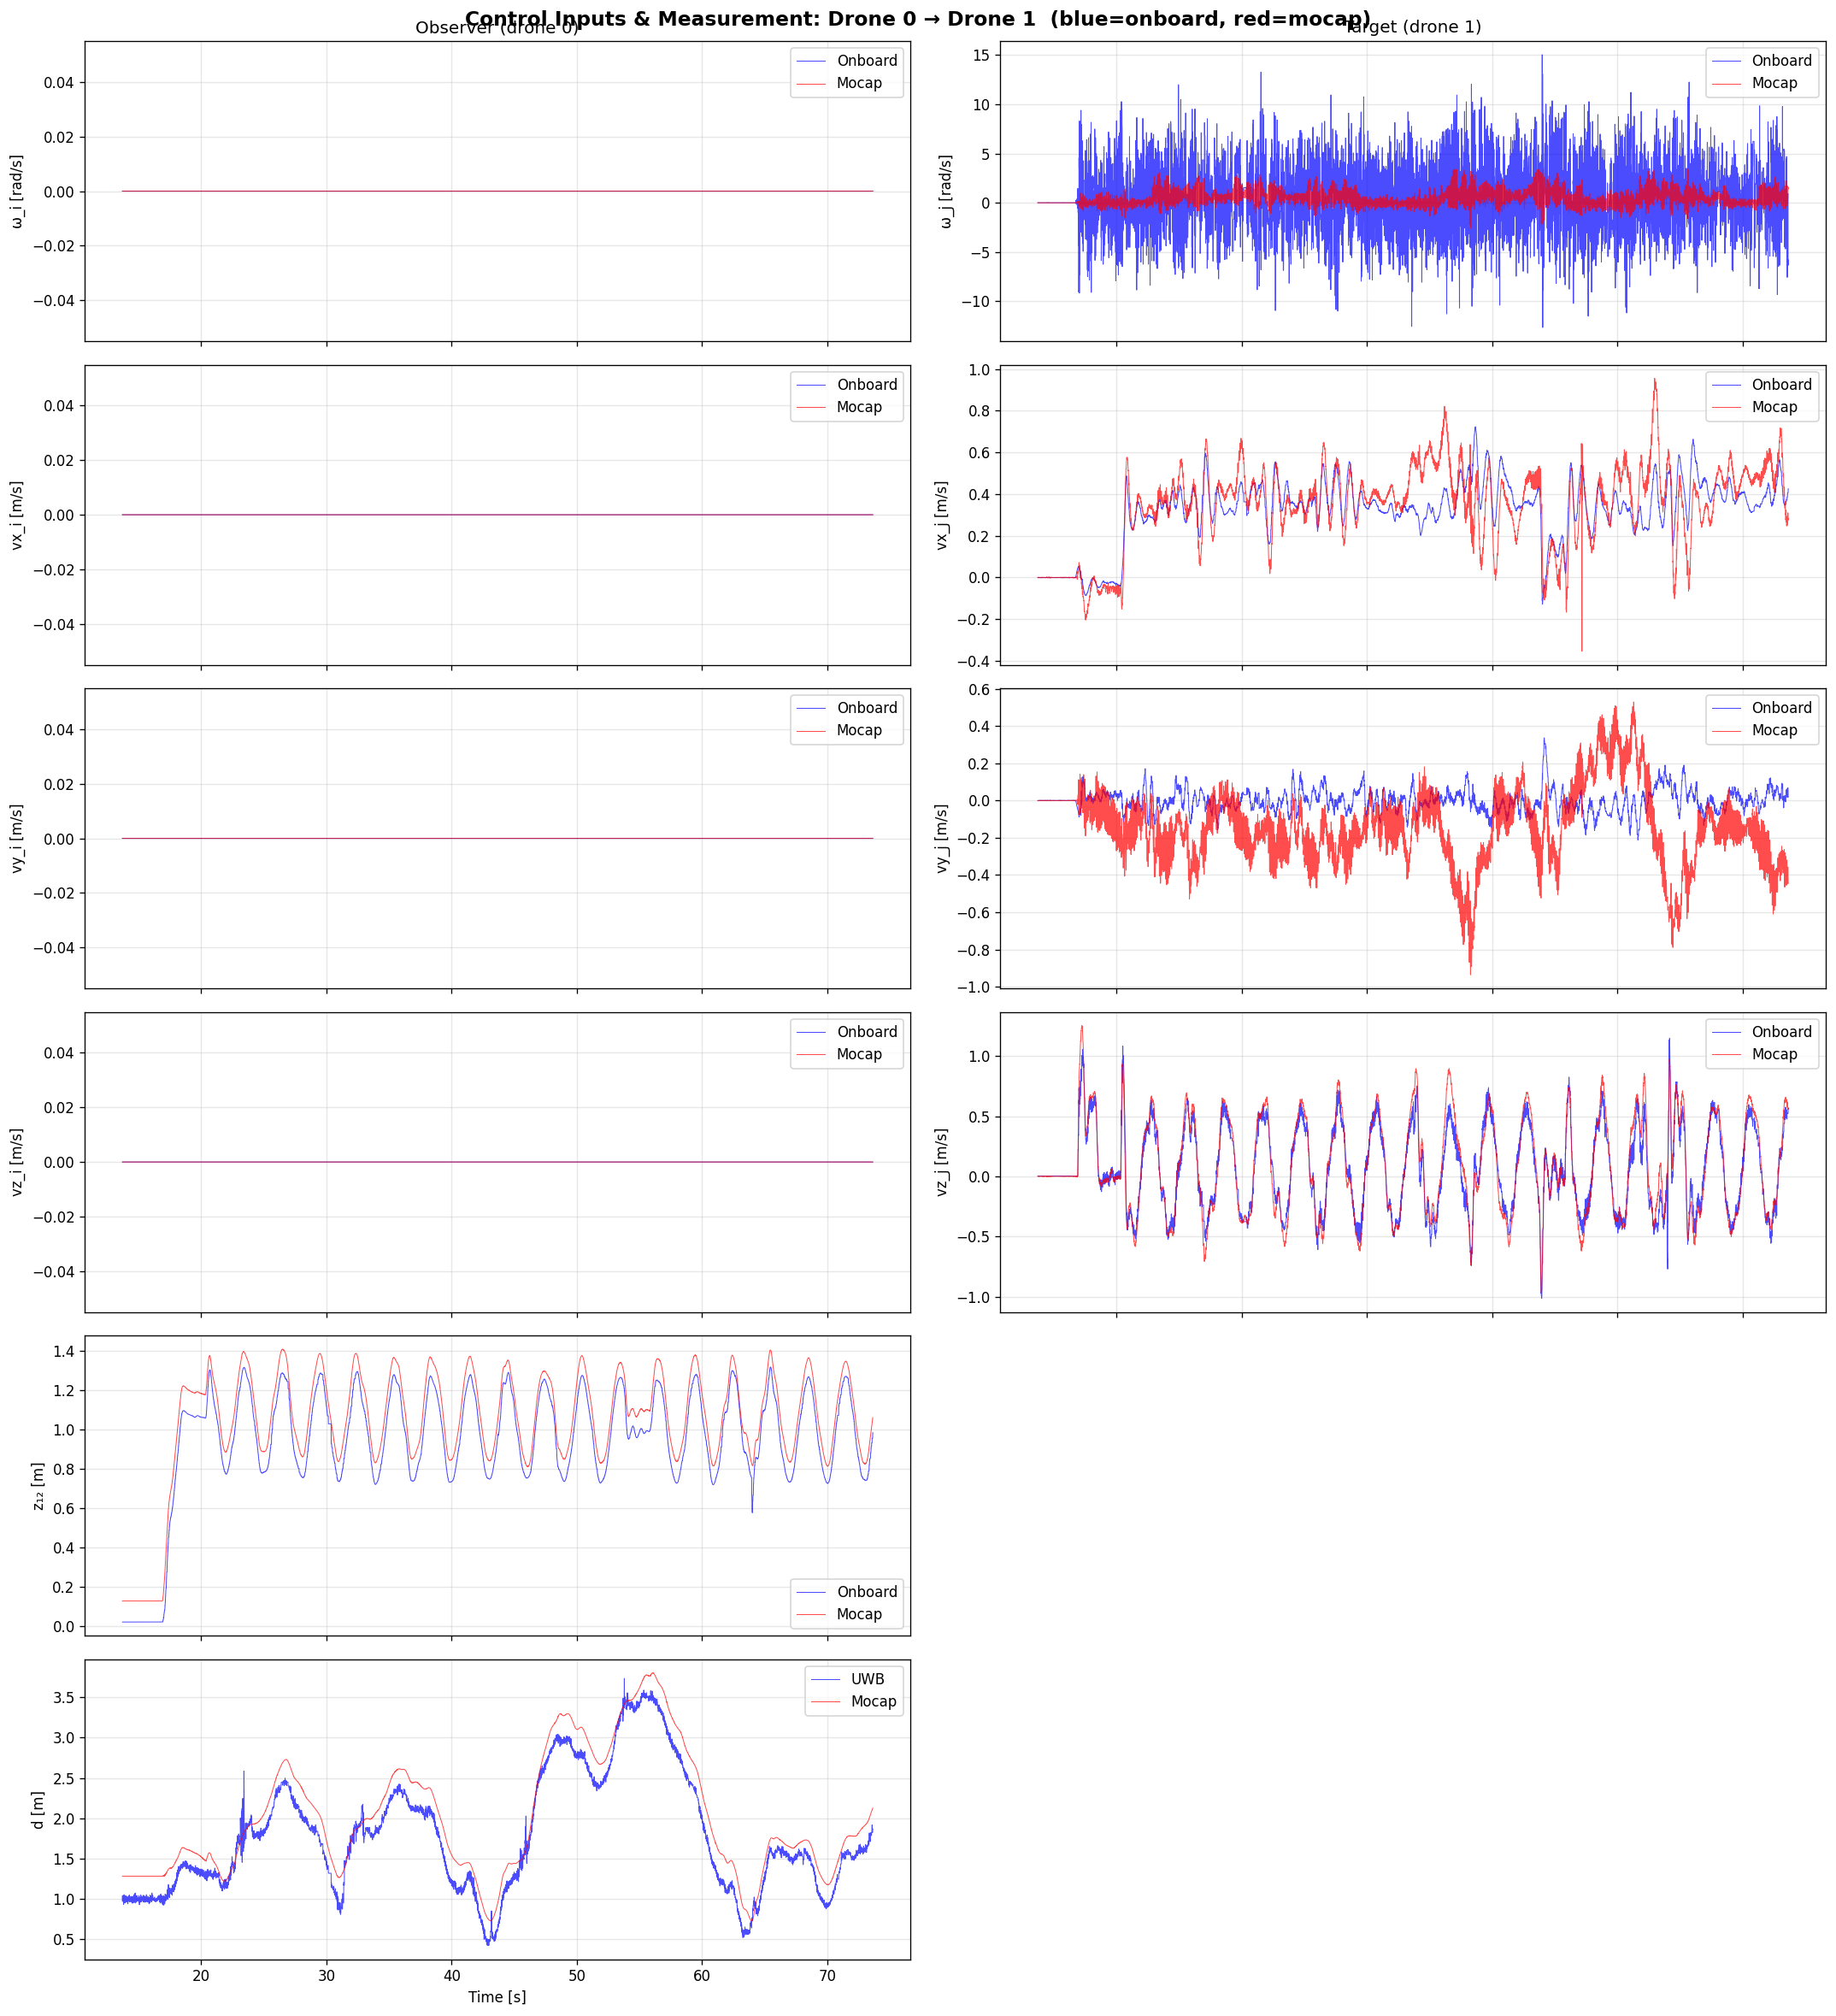

In [17]:

# ── Compare control inputs & measurement: onboard vs mocap ────────

do = data_onboard
dm = data_mocap

fig, axes = plt.subplots(6, 2, figsize=(18, 20), sharex=True)
fig.suptitle(f'Control Inputs & Measurement: Drone {i} → Drone {j}  (blue=onboard, red=mocap)',
             fontsize=14, fontweight='bold')

# Left column: observer (drone i)
# Right column: target (drone j)

# Row 0: yaw rate
axes[0, 0].plot(time, do['omega_i'], 'b-', alpha=0.7, lw=0.6, label='Onboard')
axes[0, 0].plot(time, dm['omega_i'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[0, 0].set_ylabel('ω_i [rad/s]'); axes[0, 0].set_title(f'Observer (drone {i})')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(time, do['omega_j'], 'b-', alpha=0.7, lw=0.6, label='Onboard')
axes[0, 1].plot(time, dm['omega_j'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[0, 1].set_ylabel('ω_j [rad/s]'); axes[0, 1].set_title(f'Target (drone {j})')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Row 1: vx (body frame)
axes[1, 0].plot(time, do['vxi'], 'b-', alpha=0.7, lw=0.6, label='Onboard')
axes[1, 0].plot(time, dm['vxi'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[1, 0].set_ylabel('vx_i [m/s]'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(time, do['vxj'], 'b-', alpha=0.7, lw=0.6, label='Onboard')
axes[1, 1].plot(time, dm['vxj'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[1, 1].set_ylabel('vx_j [m/s]'); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

# Row 2: vy (body frame)
axes[2, 0].plot(time, do['vyi'], 'b-', alpha=0.7, lw=0.6, label='Onboard')
axes[2, 0].plot(time, dm['vyi'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[2, 0].set_ylabel('vy_i [m/s]'); axes[2, 0].legend(); axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(time, do['vyj'], 'b-', alpha=0.7, lw=0.6, label='Onboard')
axes[2, 1].plot(time, dm['vyj'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[2, 1].set_ylabel('vy_j [m/s]'); axes[2, 1].legend(); axes[2, 1].grid(True, alpha=0.3)

# Row 3: vz (body frame)
axes[3, 0].plot(time, do['vzi'], 'b-', alpha=0.7, lw=0.6, label='Onboard')
axes[3, 0].plot(time, dm['vzi'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[3, 0].set_ylabel('vz_i [m/s]'); axes[3, 0].legend(); axes[3, 0].grid(True, alpha=0.3)

axes[3, 1].plot(time, do['vzj'], 'b-', alpha=0.7, lw=0.6, label='Onboard')
axes[3, 1].plot(time, dm['vzj'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[3, 1].set_ylabel('vz_j [m/s]'); axes[3, 1].legend(); axes[3, 1].grid(True, alpha=0.3)

# Row 4: z12 (height difference)
axes[4, 0].plot(time, do['z12'], 'b-', alpha=0.7, lw=0.6, label='Onboard')
axes[4, 0].plot(time, dm['z12'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[4, 0].set_ylabel('z₁₂ [m]'); axes[4, 0].legend(); axes[4, 0].grid(True, alpha=0.3)
axes[4, 1].set_visible(False)

# Row 5: distance measurement
axes[5, 0].plot(time, do['d_meas'], 'b-', alpha=0.7, lw=0.6, label='UWB')
axes[5, 0].plot(time, dm['d_meas'], 'r-', alpha=0.7, lw=0.6, label='Mocap')
axes[5, 0].set_ylabel('d [m]'); axes[5, 0].set_xlabel('Time [s]')
axes[5, 0].legend(); axes[5, 0].grid(True, alpha=0.3)
axes[5, 1].set_visible(False)

plt.tight_layout(); plt.show()


In [18]:

# Check initial heights from onboard vs mocap for each drone
for d in range(3):
    if d == STATIC_DRONE:
        ob_z = 0.0
    else:
        col = f'd{d}_kalman_stateZ'
        ob_z = df[col].iloc[0]
    mc_z = df[f'mc{d}_cf_z'].iloc[0]
    print(f"Drone {d}: onboard z₀ = {ob_z:.4f} m,  mocap z₀ = {mc_z:.4f} m,  diff = {mc_z - ob_z:.4f} m")


Drone 0: onboard z₀ = 0.0000 m,  mocap z₀ = 0.1226 m,  diff = 0.1226 m
Drone 1: onboard z₀ = 0.0200 m,  mocap z₀ = 0.1270 m,  diff = 0.1070 m
Drone 2: onboard z₀ = 0.0200 m,  mocap z₀ = 0.1230 m,  diff = 0.1031 m


Pair 0↔1: mean bias = -0.2253 m, std = 0.1125 m
Pair 0↔2: mean bias = -0.1981 m, std = 0.1014 m
Pair 1↔2: mean bias = -0.1148 m, std = 0.1445 m


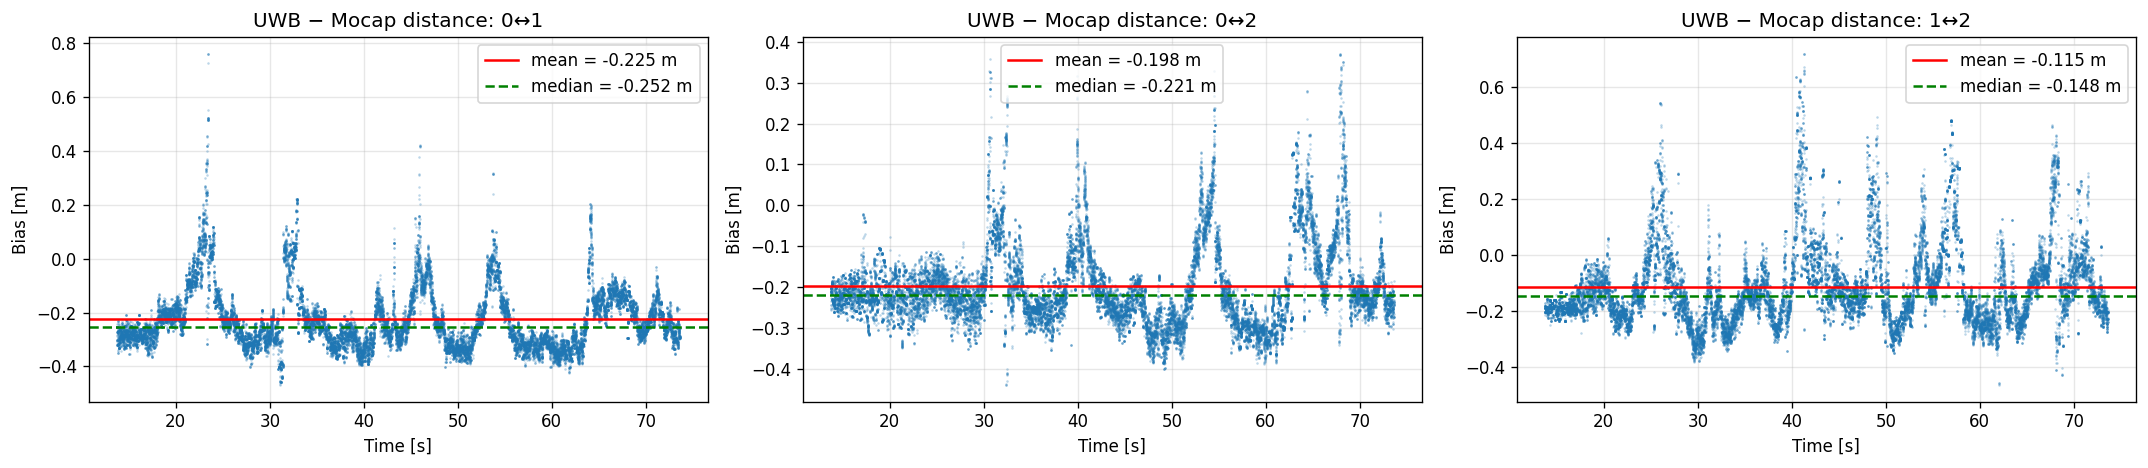

In [19]:

# UWB vs Mocap distance bias analysis
pairs = [('0', '1'), ('0', '2'), ('1', '2')]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (pi, pj) in zip(axes, pairs):
    d_uwb = df[f'd{pi}_distance{pj}'].values / 1000.0
    d_mc = df[f'mc_dist_{pi}{pj}'].values
    bias = d_uwb - d_mc
    ax.plot(time, bias, '.', ms=1, alpha=0.3)
    ax.axhline(np.mean(bias), color='r', lw=1.5, label=f'mean = {np.mean(bias):.3f} m')
    ax.axhline(np.median(bias), color='g', lw=1.5, ls='--', label=f'median = {np.median(bias):.3f} m')
    ax.set_title(f'UWB − Mocap distance: {pi}↔{pj}')
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Bias [m]')
    ax.legend(); ax.grid(True, alpha=0.3)
    print(f"Pair {pi}↔{pj}: mean bias = {np.mean(bias):.4f} m, std = {np.std(bias):.4f} m")
plt.tight_layout(); plt.show()


Drone 0: yaw diff mean=-1.2°, std=0.8°, max=2.6°
Drone 1: yaw diff mean=624.5°, std=480.3°, max=1407.7°


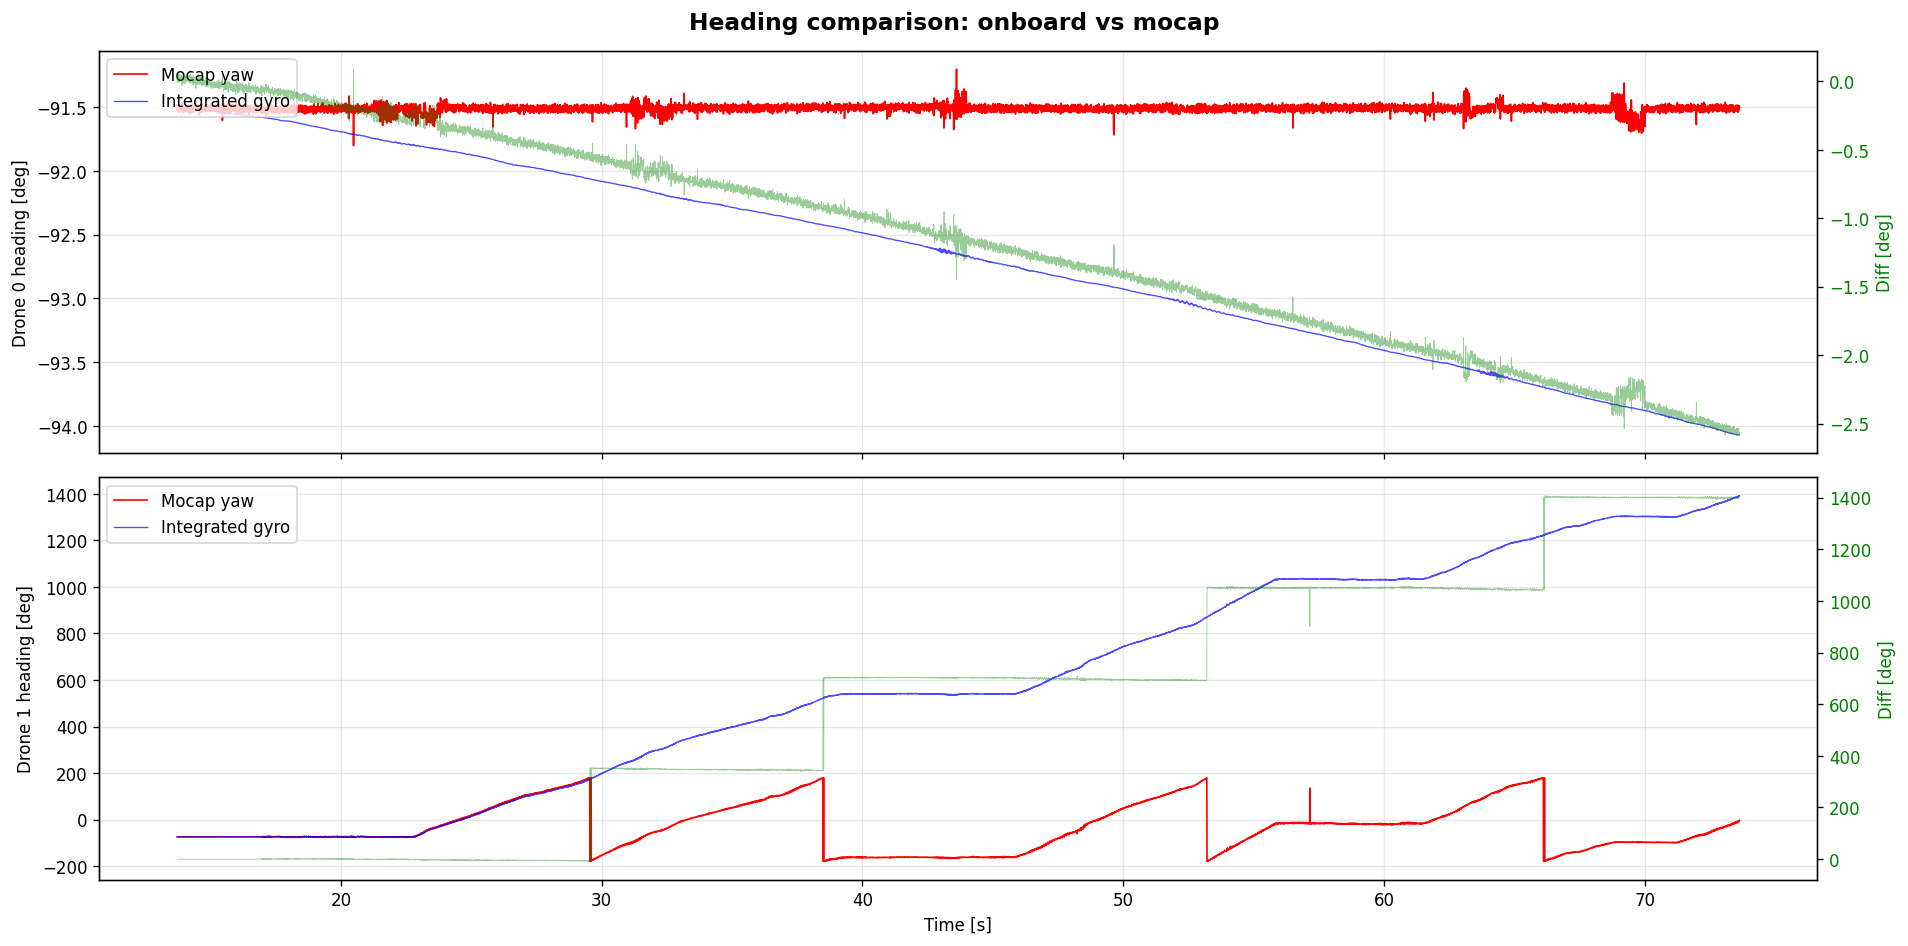

In [20]:

# ── Yaw alignment: onboard vs mocap ──────────────────────────────
# If yaw is offset, body-frame vx/vy get mixed

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Heading comparison: onboard vs mocap', fontsize=14, fontweight='bold')

for idx, drone in enumerate([i, j]):
    ax = axes[idx]
    # Onboard yaw — stateEstimateZ doesn't have yaw directly, 
    # but we can integrate the yaw rate to get relative heading
    mc_yaw = np.rad2deg(np.unwrap(df[f'mc{drone}_yaw'].values))
    
    # Integrate onboard gyro yaw rate to get heading (relative to initial)
    omega_ob = df[f'd{drone}_rateYaw'].values / 1000.0  # millirad/s → rad/s
    dt_arr = np.diff(time)
    yaw_integrated = np.zeros(len(time))
    for k in range(1, len(time)):
        yaw_integrated[k] = yaw_integrated[k-1] + omega_ob[k] * dt_arr[k-1]
    yaw_integrated_deg = np.rad2deg(yaw_integrated)
    
    # Align initial value to mocap
    yaw_integrated_deg += mc_yaw[0]
    
    ax.plot(time, mc_yaw, 'r-', lw=1, label='Mocap yaw')
    ax.plot(time, yaw_integrated_deg, 'b-', lw=0.8, alpha=0.7, label='Integrated gyro')
    ax.set_ylabel(f'Drone {drone} heading [deg]')
    
    # Show instantaneous difference
    diff = yaw_integrated_deg - mc_yaw
    ax2 = ax.twinx()
    ax2.plot(time, diff, 'g-', alpha=0.4, lw=0.5, label='Diff')
    ax2.set_ylabel('Diff [deg]', color='g')
    ax2.tick_params(axis='y', labelcolor='g')
    
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
    print(f"Drone {drone}: yaw diff mean={np.mean(diff):.1f}°, std={np.std(diff):.1f}°, max={np.max(np.abs(diff)):.1f}°")

axes[1].set_xlabel('Time [s]')
plt.tight_layout(); plt.show()
